In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
dataset_path = 'dataset'

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% train, 20% validation
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1981 images belonging to 2 classes.
Found 494 images belonging to 2 classes.


In [9]:
from tensorflow.keras import Input

# Step 4: Build CNN Model (Updated)
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')  # 2 classes: healthy, bacterial_spot
])

In [11]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

In [15]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [25]:
!pip uninstall scipy -y
# pip install scipy --upgrade

Found existing installation: scipy 1.15.2
Uninstalling scipy-1.15.2:
  Successfully uninstalled scipy-1.15.2


In [27]:
pip install scipy --upgrade

   ---------------------------------------- 0.0/46.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/46.2 MB 1.9 MB/s eta 0:00:25
   - -------------------------------------- 1.3/46.2 MB 3.1 MB/s eta 0:00:15
   - -------------------------------------- 1.6/46.2 MB 2.8 MB/s eta 0:00:16
   - -------------------------------------- 2.1/46.2 MB 2.4 MB/s eta 0:00:19
   -- ------------------------------------- 2.6/46.2 MB 2.4 MB/s eta 0:00:19
   -- ------------------------------------- 3.1/46.2 MB 2.4 MB/s eta 0:00:18
   --- ------------------------------------ 3.7/46.2 MB 2.4 MB/s eta 0:00:18
   --- ------------------------------------ 4.2/46.2 MB 2.5 MB/s eta 0:00:17
   ---- ----------------------------------- 4.7/46.2 MB 2.5 MB/s eta 0:00:17
   ---- ----------------------------------- 5.2/46.2 MB 2.5 MB/s eta 0:00:17
   ---- ----------------------------------- 5.8/46.2 MB 2.4 MB/s eta 0:00:17
   ----- ---------------------------------- 6.0/46.2 MB 2.4 MB/s eta 0:00:17
   ---

In [30]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 539ms/step - accuracy: 0.9659 - loss: 0.1114 - val_accuracy: 0.9676 - val_loss: 0.0986
Epoch 2/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 553ms/step - accuracy: 0.9653 - loss: 0.0962 - val_accuracy: 0.9656 - val_loss: 0.1071
Epoch 3/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 550ms/step - accuracy: 0.9791 - loss: 0.0896 - val_accuracy: 0.9636 - val_loss: 0.0936
Epoch 4/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.9797 - loss: 0.0859 - val_accuracy: 0.9717 - val_loss: 0.0894
Epoch 5/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 507ms/step - accuracy: 0.9798 - loss: 0.0771 - val_accuracy: 0.9656 - val_loss: 0.1058
Epoch 6/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 542ms/step - accuracy: 0.9759 - loss: 0.0792 - val_accuracy: 0.9696 - val_loss: 0.0852
Epoch 7/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 541ms/step - accuracy: 0.9763 - loss: 0.0694 - val_accuracy: 0.9717 - val_loss: 0.0832
Epoch 8/15
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 492ms/step - accuracy: 0.9747 - loss: 0.0721 - val_accu

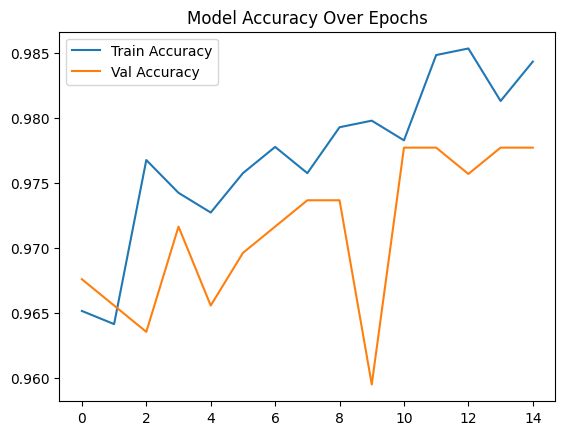

In [32]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy Over Epochs')
plt.show()

In [34]:
model.save("pepper_bell_classifier.h5")